# Neural Networks and Deep Learning

---
A.A. 2025/26 (6 CFU) - Prof. Jacopo Pegoraro, Dr. Aidin Attar, Dr. Annalisa Gallina
---

## Neural Machine Translation through Transformer

In this laboratory we implement a Transformer for **Italian-to-English neural machine translation** using PyTorch.
The goal is not to use a pretrained translation model, but to build the main components of the Transformer architecture directly:

- tokenization and batching of parallel sentences;
- token embeddings and sinusoidal positional encodings;
- encoder self-attention;
- decoder causal self-attention;
- encoder-decoder cross-attention;
- autoregressive generation at inference time.

The architecture follows the main ideas from [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762) by Vaswani et al. (2017). Compared with the original paper, this notebook uses a smaller model and a smaller dataset subset so that the experiment can be executed in a laboratory setting.


A Transformer replaces recurrent processing with attention mechanisms. Instead of reading the sentence strictly from left to right, each token can directly compare itself with the other tokens in the sequence.

The encoder reads the source sentence. The decoder generates the target sentence one token at a time. The connection between the two is the **cross-attention** mechanism.

![Transformer architecture](https://www.tensorflow.org/images/tutorials/transformer/transformer.png)

During decoding, each generated word can attend both to previous generated words and to relevant words in the input sentence.

![Transformer words](https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-words.png)


## Install and import statements

We install the libraries needed for this notebook:

- `datasets` is used to download and manipulate the parallel translation dataset;
- `transformers` provides the Marian tokenizer;
- `sentencepiece` is required by Marian tokenizers;
- PyTorch is used to implement and train the Transformer.


In [1]:
!pip install -q datasets transformers sentencepiece

In [2]:
import os, time, math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## Utility functions

Before defining the model, we implement three utility functions:

1. `positional_encoding`: creates sinusoidal position vectors, so that the model can distinguish the first token from the second, third, and so on;
2. `masked_loss`: computes cross-entropy while ignoring padding tokens;
3. `masked_accuracy`: computes token-level accuracy while ignoring padding tokens.

Padding must be ignored because different sentences have different lengths. Without masking, the model could obtain misleadingly good scores by predicting `<pad>` tokens correctly.


In [3]:
def positional_encoding(length, depth):
    """Compute sinusoidal positional encoding."""
    # Half of the dimensions are used for sine and half for cosine.
    depth = depth / 2
    positions = np.arange(length)[:, np.newaxis]
    depths    = np.arange(depth)[np.newaxis, :] / depth
    angle_rates = 1 / (10000 ** depths)
    angle_rads  = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return torch.tensor(pos_encoding, dtype=torch.float32)


def masked_loss(pred, label, pad_id):
    """Cross-entropy loss ignoring padding tokens."""
    mask = label != pad_id
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    loss = loss_fn(pred.permute(0, 2, 1), label)
    return (loss * mask).sum() / mask.sum()


def masked_accuracy(pred, label, pad_id):
    """Token accuracy ignoring padding tokens."""
    mask = label != pad_id
    correct = (pred.argmax(dim=-1) == label) & mask
    return correct.sum().float() / mask.sum()


## Dataset load

We use the OPUS-100 English-Italian parallel corpus from Hugging Face Datasets. Each example contains a pair of aligned sentences: one in Italian and one in English.

The dataset configuration is `en-it`, but in this notebook the translation direction is:

```text
Italian sentence  →  English sentence
```

For speed, we select only a subset of the training and validation sets. Increasing `N_TRAIN` and `N_VAL` usually improves translation quality, but also makes training slower.


In [6]:
N_TRAIN = 50000
N_VAL = 2000

os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['HUGGINGFACE_HUB_VERBOSITY'] = 'error'

dataset = load_dataset('Helsinki-NLP/opus-100', 'en-it')

def flatten(example):
    return {
        'it': example['translation']['it'],
        'en': example['translation']['en'],
    }

train_examples = (
    dataset['train']
    .map(flatten, remove_columns=['translation'])
    .shuffle(seed=42)
    .select(range(N_TRAIN))
)

val_examples = (
    dataset['validation']
    .map(flatten, remove_columns=['translation'])
    .select(range(N_VAL))
)

print(f'Train examples: {len(train_examples):,}')
print(f'Val examples:   {len(val_examples):,}')


README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

en-it/test-00000-of-00001.parquet:   0%|          | 0.00/223k [00:00<?, ?B/s]

en-it/train-00000-of-00001.parquet:   0%|          | 0.00/91.7M [00:00<?, ?B/s]

en-it/validation-00000-of-00001.parquet:   0%|          | 0.00/220k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train examples: 50,000
Val examples:   2,000


In [7]:
for example in train_examples.select(range(3)):
    print(f'IT: {example["it"]}')
    print(f'EN: {example["en"]}')
    print()


IT: 7. Se si sta pagando in valuta estera senza fare un controllo con la propria banca per verificare l’esistenza di costi supplementari
EN: 7. If you’re paying in a foreign currency, not double checking with your bank if any extra fees apply

IT: nenti solforati, sull’attivazione della microcircolazione e sull’attivazione dei fibroblasti che rendono la cute molto più sottile ed elastica.
EN: nents, activation of the microcirculation and activating the fibroblasts that make the skin thinner and more elastic.

IT: No, no, no.
EN: No, no, no.



## 1 - Sentence tokenization

A neural network cannot directly process raw text. Each sentence is first converted into a sequence of integer token IDs.

In this notebook we use the Marian tokenizer associated with the `Helsinki-NLP/opus-mt-it-en` model. The pretrained translation model itself is **not** used: only the tokenizer is used to split text into subword units and map them to integer IDs.

The code keeps two tokenizer variables:

```python
src_tokenizer  # used for Italian input sentences
tgt_tokenizer  # used for English target sentences
```

The dataset is pre-tokenized once with `dataset.map()`, so that training batches only need tensor conversion and padding.


In [8]:
SRC_LANG = 'it'
TGT_LANG = 'en'
MAX_TOKENS = 128


def get_tokenizers():
    # We use the Marian tokenizer associated with the Italian-to-English OPUS model.
    # The model itself is not used; only the tokenizer is used.
    src_tokenizer = AutoTokenizer.from_pretrained('Helsinki-NLP/opus-mt-it-en', use_fast=True)
    tgt_tokenizer = AutoTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-it', use_fast=True)

    # Marian tokenizers have an EOS (end of sequence) token, but not always an explicit BOS (beginning of sequence) token.
    # Adding one keeps decoder inputs and labels easy to read.
    if tgt_tokenizer.bos_token is None:
        tgt_tokenizer.add_special_tokens({'bos_token': '<bos>'})

    return src_tokenizer, tgt_tokenizer


src_tokenizer, tgt_tokenizer = get_tokenizers()

SRC_VOCAB_SIZE = len(src_tokenizer)
TGT_VOCAB_SIZE = len(tgt_tokenizer)

SRC_PAD_ID = src_tokenizer.pad_token_id
TGT_PAD_ID = tgt_tokenizer.pad_token_id
TGT_BOS_ID = tgt_tokenizer.bos_token_id
TGT_EOS_ID = tgt_tokenizer.eos_token_id

print(f'Source vocab size: {SRC_VOCAB_SIZE}  pad_id={SRC_PAD_ID}')
print(f'Target vocab size: {TGT_VOCAB_SIZE}  pad_id={TGT_PAD_ID}  bos_id={TGT_BOS_ID}  eos_id={TGT_EOS_ID}')


def tokenize(batch):
    src_ids = src_tokenizer(
        batch[SRC_LANG],
        truncation=True,
        max_length=MAX_TOKENS,
        add_special_tokens=True,
    )['input_ids']

    # We add BOS/EOS manually so that the decoder input and label are explicit.
    tgt_ids = tgt_tokenizer(
        batch[TGT_LANG],
        truncation=True,
        max_length=MAX_TOKENS - 1,
        add_special_tokens=False,
    )['input_ids']

    tgt_input = [[TGT_BOS_ID] + ids for ids in tgt_ids]
    tgt_label = [ids + [TGT_EOS_ID] for ids in tgt_ids]

    return {
        'src_ids': src_ids,
        'tgt_input': tgt_input,
        'tgt_label': tgt_label,
    }


train_data = train_examples.map(
    tokenize,
    batched=True,
    num_proc=4,
    remove_columns=[SRC_LANG, TGT_LANG],
)

val_data = val_examples.map(
    tokenize,
    batched=True,
    num_proc=4,
    remove_columns=[SRC_LANG, TGT_LANG],
)

train_data.set_format('numpy')
val_data.set_format('numpy')

print('Pre-tokenization done.')
print(f'Sample source ids: {train_data[0]["src_ids"]}')
print(f'Sample target input ids: {train_data[0]["tgt_input"]}')
print(f'Sample target label ids: {train_data[0]["tgt_label"]}')


config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/814k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/790k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.37M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.35M [00:00<?, ?B/s]

Source vocab size: 80379  pad_id=80378
Target vocab size: 80036  pad_id=80034  bos_id=80035  eos_id=0


Map (num_proc=4):   0%|          | 0/50000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2000 [00:00<?, ? examples/s]

Pre-tokenization done.
Sample source ids: [ 5650   136    60   310  1225  3090     7  7159 12083   430   321    23
   959    43    15  1831  6364    20  6304    35     1  6252     6  1861
  7117     0]
Sample target input ids: [80035  6036   374    29     1    51 10431     7     9  3343  5554     3
    74  1993 14238    41    87  4480   216   256  2535  9991  1826]
Sample target label ids: [ 6036   374    29     1    51 10431     7     9  3343  5554     3    74
  1993 14238    41    87  4480   216   256  2535  9991  1826     0]


## Tokenizers, token IDs, and word embeddings

Neural networks cannot directly process raw text such as:

```text
"ciao, come stai?"
```

A **tokenizer** converts text into a sequence of discrete units called **tokens**.  
Depending on the tokenizer, a token may correspond to a full word, part of a word, punctuation, or a special symbol.

For example, a sentence may be transformed into something like:

```text
"ciao, come stai?"  →  ["ciao", ",", "come", "stai", "?"]
```

Each token is then mapped to an integer ID using a **vocabulary**:

```text
["ciao", ",", "come", "stai", "?"]  →  [245, 12, 98, 157, 7]
```

These integer IDs are still not meaningful numerical representations.  
They are only indices. The role of the **embedding layer** is to map each token ID to a dense vector:

```text
token ID 245  →  [0.12, -0.08, 0.31, ..., 0.05]
```

So the full pipeline is:

```text
text → tokens → token IDs → embedding vectors
```

The tokenizer gives us the token IDs, while the Transformer learns the embedding vectors during training.

More specifically:

- the **source tokenizer** converts Italian sentences into source token IDs;
- the **target tokenizer** converts English sentences into target token IDs;
- the encoder embedding layer maps source token IDs to vectors;
- the decoder embedding layer maps target token IDs to vectors.

Even if two tokenizers come from the same pretrained Marian model, the important conceptual distinction is that the encoder receives source-language tokens, while the decoder receives target-language tokens.

Special tokens are also important:

```text
<BOS>  beginning of sequence
<EOS>  end of sequence
<PAD>  padding token used to make sequences in a batch have the same length
```

During training, the decoder receives the target sentence shifted to the right:

```text
decoder input:  <BOS>  I  am  fine
label:          I      am fine <EOS>
```

This teaches the model to predict the next target token at every position.

### Decoder input and training target

During training, the decoder receives the correct target sentence shifted by one position. This technique is called **teacher forcing**.

For example, if the target sentence is:

```text
this is a test
```

we build two sequences:

```text
decoder input:  <bos> this is a test
target label:   this is a test <eos>
```

At each position, the decoder sees the previous target tokens and learns to predict the next token.

This shifted setup is important: the model is not asked to reproduce the whole sentence at once. It learns the conditional distribution

```text
P(next token | source sentence, previous target tokens)
```


### Prepare the data pipeline with PyTorch `DataLoader`

After tokenization, every sentence is represented as a list of token IDs. Since sentences have different lengths, the `collate_fn` pads them dynamically inside each batch.

The `DataLoader` returns batches in the form:

```python
(src_batch, tgt_input_batch), tgt_label_batch
```

where:

- `src_batch` is the Italian input sequence;
- `tgt_input_batch` is the shifted English sequence given to the decoder;
- `tgt_label_batch` is the expected next-token sequence.

The shapes are typically:

```text
src_batch:       (batch_size, source_length)
tgt_input_batch: (batch_size, target_length)
tgt_label_batch: (batch_size, target_length)
```


In [9]:
BATCH_SIZE = 16


class TranslationDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]
        return (
            torch.as_tensor(ex['src_ids'], dtype=torch.long),
            torch.as_tensor(ex['tgt_input'], dtype=torch.long),
            torch.as_tensor(ex['tgt_label'], dtype=torch.long),
        )


def collate_fn(batch):
    src_batch, tgt_input_batch, tgt_label_batch = zip(*batch)

    src_batch = nn.utils.rnn.pad_sequence(
        src_batch,
        batch_first=True,
        padding_value=SRC_PAD_ID,
    )

    tgt_input_batch = nn.utils.rnn.pad_sequence(
        tgt_input_batch,
        batch_first=True,
        padding_value=TGT_PAD_ID,
    )

    tgt_label_batch = nn.utils.rnn.pad_sequence(
        tgt_label_batch,
        batch_first=True,
        padding_value=TGT_PAD_ID,
    )

    return (src_batch, tgt_input_batch), tgt_label_batch


train_dataset = TranslationDataset(train_data)
val_dataset = TranslationDataset(val_data)

pin_memory = device.type == 'cuda'

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=pin_memory,
)

for (src, tgt_inp), tgt_lbl in train_loader:
    print('source shape:      ', src.shape)
    print('target input shape:', tgt_inp.shape)
    print('target label shape:', tgt_lbl.shape)
    break


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


source shape:       torch.Size([16, 46])
target input shape: torch.Size([16, 51])
target label shape: torch.Size([16, 51])


In [10]:
# Inspect one batch to verify the shift between decoder input and target label.
(src, tgt_input), tgt_label = next(iter(train_loader))

print('Decoded decoder input example:')
print(tgt_tokenizer.decode(tgt_input[0], skip_special_tokens=False))

print('Decoded target label example:')
print(tgt_tokenizer.decode(tgt_label[0], skip_special_tokens=False))


Decoded decoder input example:
<bos> The Tea Party has gained a sizable following based on their message of low taxes, limited government, and happy birthday, Tom...
Decoded target label example:
The Tea Party has gained a sizable following based on their message of low taxes, limited government, and happy birthday, Tom...</s>


## 2 - Embedding and Positional Encoding Layer

The tokenizer gives us integer token IDs, but attention layers operate on continuous vectors. The embedding layer maps each token ID to a vector of size `key_dim`.

However, attention alone has no built-in notion of token order. The sequence

```text
the cat eats fish
```

and a permutation of the same tokens would contain the same token embeddings. To encode order, we add a **positional encoding** vector to each token embedding.

In this notebook we use the sinusoidal positional encoding introduced in the original Transformer paper.


In [11]:
class PositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, key_dim, pad_id=0):
        super().__init__()
        self.key_dim = key_dim
        self.pad_id  = pad_id
        self.embedding = nn.Embedding(vocab_size, key_dim, padding_idx=pad_id)
        # Register as buffer: it is moved with the model to CPU/GPU, but it is not trained.
        self.register_buffer('pos_encoding', positional_encoding(length=2048, depth=key_dim))

    def forward(self, x):
        seq_len = x.size(1)
        x = self.embedding(x) * math.sqrt(self.key_dim)
        x = x + self.pos_encoding[:seq_len, :]
        return x

    def get_padding_mask(self, x):
        return x == self.pad_id  # True where padding


### Attention blocks used by the model

The Transformer uses three attention operations.

1. **Encoder self-attention**: each source token attends to the other source tokens. This lets the encoder build contextual representations of the Italian sentence.
2. **Decoder causal self-attention**: each target token attends only to previous target tokens. This prevents the decoder from seeing the future during training.
3. **Cross-attention**: each decoder token attends to the encoder output. This is where the decoder decides which parts of the source sentence are useful for generating the next English token.

The encoder processes the input sentence once. The decoder then generates the translation autoregressively, one token at a time.


### Masks

Two masks are used in the attention layers.

- **Padding mask**: prevents the model from attending to `<pad>` tokens inserted only to create fixed-size batches.
- **Causal mask**: prevents the decoder from attending to future target tokens.

The encoder uses only the padding mask. The decoder self-attention uses both padding and causal masking. The cross-attention uses the padding mask of the source sentence.

In PyTorch's boolean masks for `nn.MultiheadAttention`, `True` marks positions that should be ignored.


### Transformer architecture

The model is composed of an encoder and a decoder.

- The **encoder** converts the Italian sentence into contextual vectors.
- The **decoder** uses previously generated English tokens plus the encoder output to predict the next token.
- The final linear layer maps decoder vectors to logits over the target vocabulary.

The diagram below highlights the three attention mechanisms used in the model.


## 3 - Building blocks: Base Attention Layer

All attention layers in this notebook are implemented using PyTorch's `nn.MultiheadAttention`.

The `BaseAttention` class stores the common components:

- the multi-head attention module;
- a residual connection;
- a layer normalization step;
- optionally, the last attention weights for visualization.

The specific behavior depends on how `query`, `key`, and `value` are passed in the child classes.


### Scaled dot-product attention

The core operation of attention compares queries and keys to produce attention weights, then uses those weights to combine values.

Conceptually:

```text
attention weights = softmax(query · key / sqrt(d_k))
output            = attention weights · value
```

Multi-head attention repeats this operation in several learned subspaces. This allows different heads to focus on different relationships, such as local context, long-range dependencies, or alignment between source and target tokens.


In [12]:
class BaseAttention(nn.Module):
    def __init__(self, num_heads, key_dim, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=key_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.layernorm = nn.LayerNorm(key_dim)
        self.last_attn_scores = None


## 4 - Building blocks: The Three Attention Layers

The same attention mechanism is reused in three different ways.

- In **cross-attention**, the decoder state is the query and the encoder output provides keys and values.
- In **global self-attention**, query, key and value all come from the encoder sequence.
- In **causal self-attention**, query, key and value all come from the decoder sequence, but future positions are masked.


![Attention layers](https://drive.usercontent.google.com/download?id=13KR20J3SzRAjQ49phGHX1KSLZm7jLYWk&export=view&authuser=0)

In [13]:
class CrossAttention(BaseAttention):
    """Attends from the decoder (query=x) to the encoder output (key/value=context)."""
    def forward(self, x, context, key_padding_mask=None):
        attn_output, attn_scores = self.mha(
            query=x,
            key=context,
            value=context,
            key_padding_mask=key_padding_mask,  # mask encoder padding
            need_weights=True,
            average_attn_weights=False,          # keep per-head weights
        )
        self.last_attn_scores = attn_scores      # (batch, heads, tgt_len, src_len)
        x = self.layernorm(x + attn_output)
        return x


class GlobalSelfAttention(BaseAttention):
    """Full (bidirectional) self-attention used in the encoder."""
    def forward(self, x, key_padding_mask=None):
        attn_output, _ = self.mha(
            query=x, key=x, value=x,
            key_padding_mask=key_padding_mask,
        )
        x = self.layernorm(x + attn_output)
        return x


class CausalSelfAttention(BaseAttention):
    """Masked (causal) self-attention used in the decoder — cannot attend to future tokens."""
    def forward(self, x, key_padding_mask=None):
        seq_len = x.size(1)
        # Upper-triangular mask: position i cannot attend to positions > i
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device), diagonal=1
        ).bool()
        attn_output, _ = self.mha(
            query=x, key=x, value=x,
            attn_mask=causal_mask,               # additive mask: True positions are -inf
            key_padding_mask=key_padding_mask,
        )
        x = self.layernorm(x + attn_output)
        return x

## 5 - Building blocks: Feed Forward Network

After attention, each token representation is passed through the same small feed-forward network.

This block is applied independently to every position:

```text
Linear(key_dim → dff) → ReLU → Linear(dff → key_dim)
```

The residual connection and layer normalization help stabilize optimization, especially when stacking several Transformer layers.


In [14]:
class FeedForward(nn.Module):
    def __init__(self, key_dim, dff, dropout_rate=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(key_dim, dff),
            nn.ReLU(),
            nn.Linear(dff, key_dim),
            nn.Dropout(dropout_rate),
        )
        self.layer_norm = nn.LayerNorm(key_dim)

    def forward(self, x):
        x = self.layer_norm(x + self.net(x))
        return x

## 6 - The Encoder

An encoder layer contains:

1. global self-attention over the source sentence;
2. a feed-forward network.

The full encoder stacks multiple encoder layers. The output has shape:

```text
(batch_size, source_length, key_dim)
```

Each output vector represents one source token, but enriched with contextual information from the whole input sentence.


In [15]:
class EncoderLayer(nn.Module):
    def __init__(self, *, key_dim, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = GlobalSelfAttention(
            num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate)
        self.ffn = FeedForward(key_dim, dff, dropout_rate)

    def forward(self, x, padding_mask=None):
        x = self.self_attention(x, key_padding_mask=padding_mask)
        x = self.ffn(x)
        return x


class Encoder(nn.Module):
    def __init__(self, *, num_layers, key_dim, num_heads, dff,
                 vocab_size, dropout_rate=0.1, pad_id=0):
        super().__init__()
        self.pos_embedding = PositionalEmbedding(vocab_size, key_dim, pad_id=pad_id)
        self.enc_layers = nn.ModuleList([
            EncoderLayer(key_dim=key_dim, num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        padding_mask = self.pos_embedding.get_padding_mask(x)
        x = self.dropout(self.pos_embedding(x))
        for layer in self.enc_layers:
            x = layer(x, padding_mask=padding_mask)
        return x


## 7 - The Decoder

A decoder layer contains:

1. causal self-attention over the partial target sentence;
2. cross-attention over the encoder output;
3. a feed-forward network.

The causal self-attention models the already generated English prefix. The cross-attention then aligns that prefix with the Italian source sentence.

The decoder stores the cross-attention weights from the last layer so that they can be visualized later.


In [16]:
class DecoderLayer(nn.Module):
    def __init__(self, *, key_dim, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.causal_self_attention = CausalSelfAttention(
            num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate)
        self.cross_attention = CrossAttention(
            num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate)
        self.ffn = FeedForward(key_dim, dff, dropout_rate)
        self.last_attn_scores = None

    def forward(self, x, context, tgt_padding_mask=None, src_padding_mask=None):
        x = self.causal_self_attention(x, key_padding_mask=tgt_padding_mask)
        x = self.cross_attention(x, context, key_padding_mask=src_padding_mask)
        self.last_attn_scores = self.cross_attention.last_attn_scores
        x = self.ffn(x)
        return x


class Decoder(nn.Module):
    def __init__(self, *, num_layers, key_dim, num_heads, dff,
                 vocab_size, dropout_rate=0.1, pad_id=0):
        super().__init__()
        self.pos_embedding = PositionalEmbedding(vocab_size, key_dim, pad_id=pad_id)
        self.dropout = nn.Dropout(dropout_rate)
        self.dec_layers = nn.ModuleList([
            DecoderLayer(key_dim=key_dim, num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ])
        self.last_attn_scores = None

    def forward(self, x, context, src_padding_mask=None):
        tgt_padding_mask = self.pos_embedding.get_padding_mask(x)
        x = self.dropout(self.pos_embedding(x))
        for layer in self.dec_layers:
            x = layer(x, context,
                      tgt_padding_mask=tgt_padding_mask,
                      src_padding_mask=src_padding_mask)
        self.last_attn_scores = self.dec_layers[-1].last_attn_scores
        return x


## 8 - The Transformer

The full Transformer combines:

```text
source token IDs → encoder → contextual source representations
previous target token IDs + encoder output → decoder → target logits
```

The output tensor, after a Linear layer is applied, has shape:

```text
(batch_size, target_length, target_vocab_size)
```

For each target position, the model produces one score for every token in the target vocabulary. During training, these logits are compared with the shifted target labels using cross-entropy.


In [17]:
class Transformer(nn.Module):
    def __init__(self, *, num_layers, key_dim, num_heads, dff,
                 input_vocab_size, target_vocab_size,
                 src_pad_id=0, tgt_pad_id=0, dropout_rate=0.1):
        super().__init__()
        self.encoder = Encoder(
            num_layers=num_layers, key_dim=key_dim, num_heads=num_heads, dff=dff,
            vocab_size=input_vocab_size, dropout_rate=dropout_rate, pad_id=src_pad_id)
        self.decoder = Decoder(
            num_layers=num_layers, key_dim=key_dim, num_heads=num_heads, dff=dff,
            vocab_size=target_vocab_size, dropout_rate=dropout_rate, pad_id=tgt_pad_id)
        self.final_layer = nn.Linear(key_dim, target_vocab_size)

    def forward(self, context, x):
        # context: source sentence token ids, shape (batch, src_len)
        # x: decoder input token ids, shape (batch, tgt_len)
        src_padding_mask = self.encoder.pos_embedding.get_padding_mask(context)
        # Encode the source sentence once.
        context = self.encoder(context)
        # Decode the target prefix while attending to the encoded source.
        x = self.decoder(x, context, src_padding_mask=src_padding_mask)
        return self.final_layer(x)


num_layers = 4
key_dim = 128
num_heads = 8
dff = 512
dropout_rate = 0.1

transformer = Transformer(
    num_layers=num_layers,
    key_dim=key_dim,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=SRC_VOCAB_SIZE,
    target_vocab_size=TGT_VOCAB_SIZE,
    src_pad_id=SRC_PAD_ID,
    tgt_pad_id=TGT_PAD_ID,
    dropout_rate=dropout_rate,
).to(device)

print(f'Source vocab size: {SRC_VOCAB_SIZE}')
print(f'Target vocab size: {TGT_VOCAB_SIZE}')
print(f'Total parameters:  {sum(p.numel() for p in transformer.parameters()):,}')


Source vocab size: 80379
Target vocab size: 80036
Total parameters:  32,709,156


## 9 - Training

### 9a - Custom learning rate schedule

The original Transformer uses Adam with a custom learning rate schedule. The learning rate first increases linearly during a **warmup** phase and then decreases proportionally to the inverse square root of the training step.

This schedule is useful because training deep attention models can be unstable at the beginning. Warmup avoids taking overly large optimization steps before the model has learned useful representations.


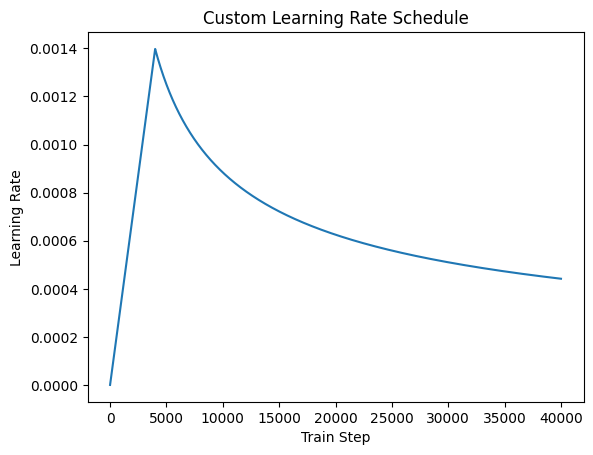

In [ ]:
class CustomSchedule:
    """Transformer learning rate schedule from the original paper."""
    def __init__(self, key_dim, warmup_steps=4000):
        self.key_dim = key_dim
        self.warmup_steps = warmup_steps
        self._step = 0

    def __call__(self, step=None):
        if step is None:
            self._step += 1
            step = self._step
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.key_dim ** -0.5) * min(arg1, arg2)


lr_schedule = CustomSchedule(key_dim)

# Visualize the learning rate curve
steps = np.arange(1, 40001)
lrs = [lr_schedule(s) for s in steps]
plt.plot(steps, lrs)
plt.ylabel('Learning Rate')
plt.xlabel('Train Step')
plt.title('Custom Learning Rate Schedule')
plt.show()

### 9b - Training loop

The training loop uses teacher forcing:

```python
logits = model(src, tgt_input)
loss   = masked_loss(logits, tgt_label)
```

The model receives the source sentence and the shifted decoder input. The loss compares the predicted next-token distribution with the shifted target labels.

The loop also clips gradients with `clip_grad_norm_`. This is a common safety measure to avoid very large gradient updates during sequence-model training.


In [ ]:
LOAD_WEIGHTS = False
load_weights_path = 'my_transformer_weights.pth'

In [ ]:
optimizer = torch.optim.Adam(transformer.parameters(), betas=(0.9, 0.98), eps=1e-9)
lr_schedule = CustomSchedule(key_dim)


def train_one_epoch(model, loader, optimizer, schedule):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for (src, tgt_inp), tgt_lbl in tqdm(loader):
        src = src.to(device, non_blocking=True)
        tgt_inp = tgt_inp.to(device, non_blocking=True)
        tgt_lbl = tgt_lbl.to(device, non_blocking=True)

        for param_group in optimizer.param_groups:
            param_group['lr'] = schedule()

        optimizer.zero_grad()
        logits = model(src, tgt_inp)
        loss = masked_loss(logits, tgt_lbl, pad_id=TGT_PAD_ID)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            acc = masked_accuracy(logits, tgt_lbl, pad_id=TGT_PAD_ID)

        total_loss += loss.item()
        total_acc += acc.item()
        n += 1

    return total_loss / n, total_acc / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for (src, tgt_inp), tgt_lbl in loader:
        src = src.to(device, non_blocking=True)
        tgt_inp = tgt_inp.to(device, non_blocking=True)
        tgt_lbl = tgt_lbl.to(device, non_blocking=True)

        logits = model(src, tgt_inp)
        total_loss += masked_loss(logits, tgt_lbl, pad_id=TGT_PAD_ID).item()
        total_acc += masked_accuracy(logits, tgt_lbl, pad_id=TGT_PAD_ID).item()
        n += 1

    return total_loss / n, total_acc / n


EPOCHS = 15
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

if LOAD_WEIGHTS:
    transformer.load_state_dict(torch.load(load_weights_path, map_location=device))
    print('Weights loaded.')

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(transformer, train_loader, optimizer, lr_schedule)
    val_loss, val_acc = evaluate(transformer, val_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f'Epoch {epoch} | {time.time() - start:.0f}s | '
        f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
        f'val loss {val_loss:.4f} acc {val_acc:.4f}'
    )
    if val_acc == max(history['val_acc']):
        print('Saving weights...')
        torch.save(transformer.state_dict(), 'my_transformer_weights.pth')
        print('Weights saved.')

torch.save(transformer.state_dict(), 'my_transformer_weights.pt')


  2%|▏         | 70/3125 [00:18<08:44,  5.82it/s]

### Training curves

The curves below are mainly diagnostic.

- The loss should generally decrease during training.
- The masked accuracy should generally increase.
- A large gap between training and validation curves may indicate overfitting.

With a small number of epochs or a reduced dataset, these curves should not be interpreted as a final evaluation of translation quality.


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Masked accuracy')
plt.legend()
plt.grid(True)
plt.show()


The resulting training curves obtained after 64 epochs are shown below:
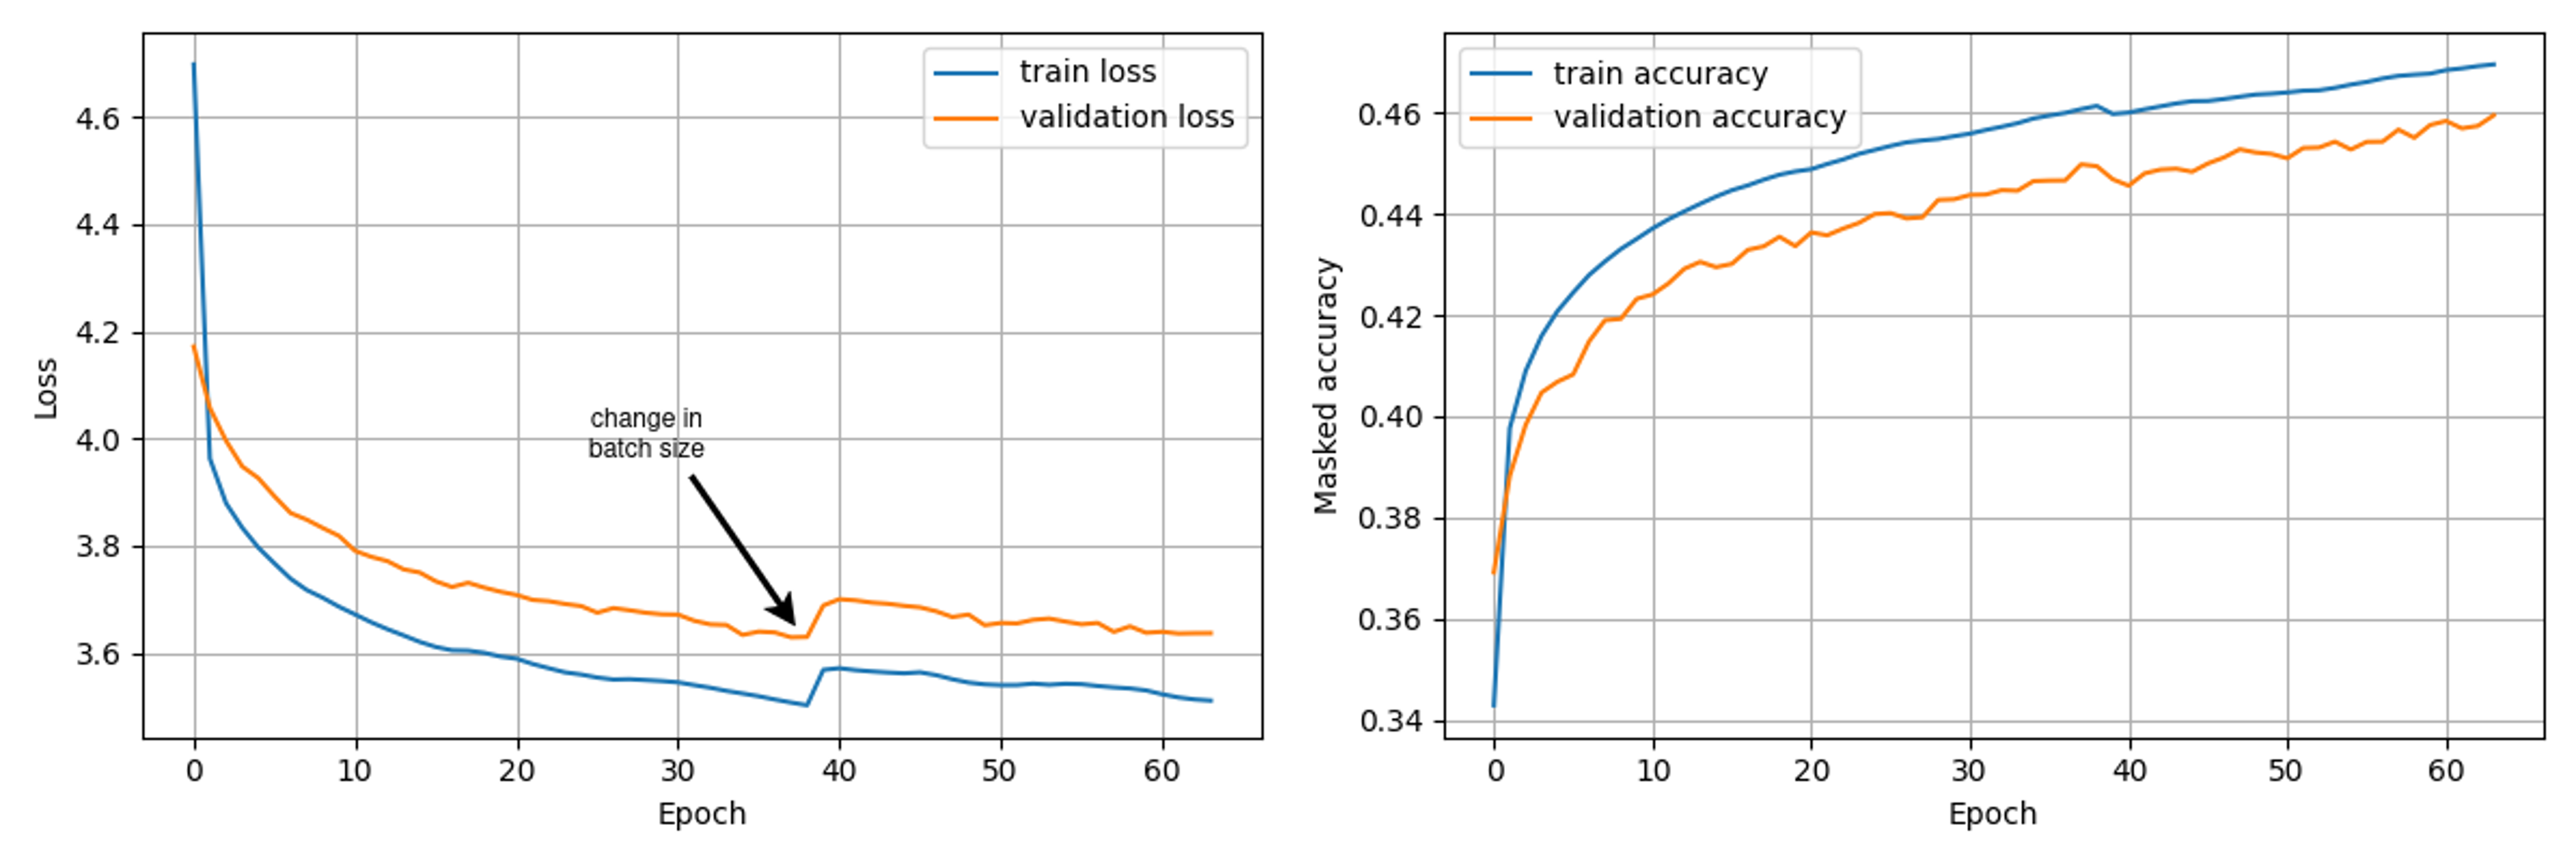

In [18]:
weights_path = 'my_transformer_weights_best.pt'

if os.path.exists(weights_path):
    try:
        transformer.load_state_dict(torch.load(weights_path, map_location=device))
        print('Weights loaded.')
    except RuntimeError as err:
        print('Weights were found, but they are not compatible with this model definition.')
        print(err)
else:
    print('No saved weights found. Train the model first if you want to create them.')


Weights loaded.


## 10 - Create the Translator

During training, the decoder receives the correct previous target tokens. At inference time, the target sentence is not available.

The translator therefore performs **autoregressive decoding**:

1. encode the Italian input sentence;
2. start the decoder with `<bos>`;
3. predict the next token;
4. append the predicted token to the decoder input;
5. repeat until `<eos>` or `MAX_TOKENS`.

This implementation uses greedy decoding: at each step, it selects the token with the highest probability.


At inference time, the target sentence is not available. The decoder starts from `<bos>`, predicts one token, appends it to the partial output, and repeats the process until `<eos>` is generated or the maximum length is reached.

Greedy decoding is simple and fast, but it is not always optimal. More advanced systems often use beam search or sampling-based decoding.


In [19]:
class Translator:
    def __init__(self, src_tokenizer, tgt_tokenizer, transformer, device):
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer
        self.transformer = transformer
        self.device = device

    @torch.no_grad()
    def __call__(self, sentence: str, max_length: int = MAX_TOKENS):
        self.transformer.eval()

        src_ids = self.src_tokenizer.encode(
            sentence,
            truncation=True,
            max_length=max_length,
            add_special_tokens=True,
        )
        encoder_input = torch.tensor([src_ids], dtype=torch.long, device=self.device)

        src_mask = self.transformer.encoder.pos_embedding.get_padding_mask(encoder_input)
        context = self.transformer.encoder(encoder_input)

        output_ids = [TGT_BOS_ID]
        attention_weights = None

        for _ in range(max_length):
            dec_input = torch.tensor([output_ids], dtype=torch.long, device=self.device)
            x = self.transformer.decoder(dec_input, context, src_padding_mask=src_mask)
            logits = self.transformer.final_layer(x)
            attention_weights = self.transformer.decoder.last_attn_scores

            next_id = logits[0, -1, :].argmax().item()
            output_ids.append(next_id)

            if next_id == TGT_EOS_ID:
                break

        text = self.tgt_tokenizer.decode(output_ids[1:], skip_special_tokens=True)
        tokens = self.tgt_tokenizer.convert_ids_to_tokens(output_ids)
        return text, tokens, attention_weights


translator = Translator(src_tokenizer, tgt_tokenizer, transformer, device)


def print_translation(sentence, prediction, ground_truth):
    print(f'{"Input:":15s}: {sentence}')
    print(f'{"Prediction":15s}: {prediction}')
    print(f'{"Ground truth":15s}: {ground_truth}')


In [20]:
sentence     = "Non capisco perché il computer sia così lento."
ground_truth = "I do not understand why the computer is so slow."
text, tokens, attn = translator(sentence)
print_translation(sentence, text, ground_truth)


Input:         : Non capisco perché il computer sia così lento.
Prediction     : I don't understand why the computer is so slow.
Ground truth   : I do not understand why the computer is so slow.


In [21]:
sentence     = "Grazie per il tuo aiuto."
ground_truth = "Thank you for your help."
text, tokens, attn = translator(sentence)
print_translation(sentence, text, ground_truth)


Input:         : Grazie per il tuo aiuto.
Prediction     : Thank you for your help.
Ground truth   : Thank you for your help.


## 11 - Attention Visualization

The cross-attention weights can be visualized as a matrix.

- The x-axis contains the input Italian tokens.
- The y-axis contains the generated English tokens.
- A brighter cell means that the decoder gave more attention to that source token while generating that target token.

Attention plots are useful for inspecting source-target alignment, but they should not be interpreted as a complete explanation of the model's decision process.


Input:         : abbiamo visto un film ieri.
Prediction     : We saw a movie yesterday.
Ground truth   : We watched a movie yesterday.


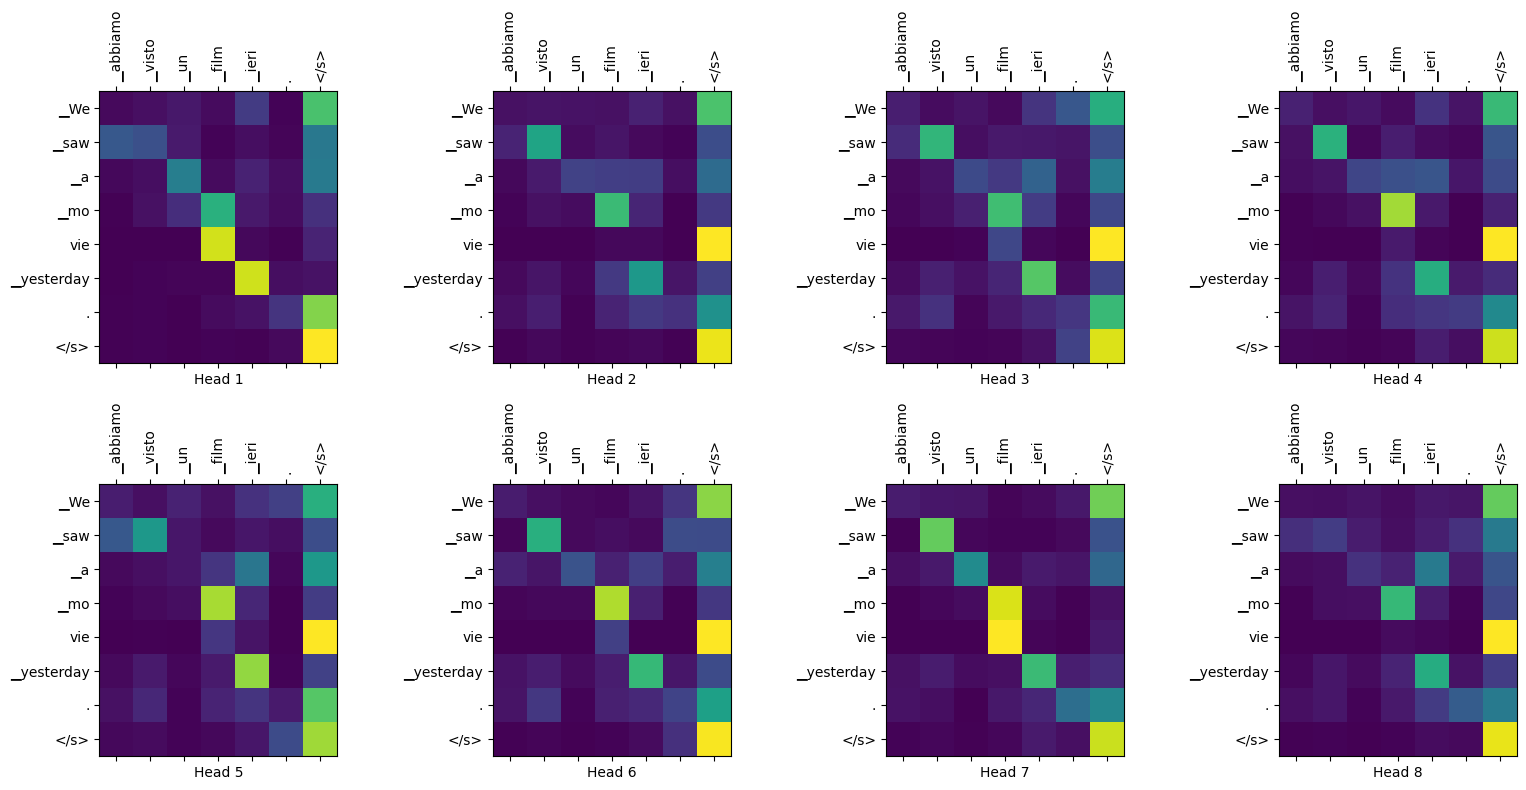

In [34]:
def plot_attention_head(in_tokens, translated_tokens, attention):
    translated_tokens = translated_tokens[1:]

    ax = plt.gca()
    ax.matshow(attention.cpu().numpy())
    ax.set_xticks(range(len(in_tokens)))
    ax.set_yticks(range(len(translated_tokens)))
    ax.set_xticklabels(in_tokens, rotation=90)
    ax.set_yticklabels(translated_tokens)


def plot_attention_weights(sentence, translated_tokens, attention_heads):
    src_ids = src_tokenizer.encode(sentence, add_special_tokens=True)
    in_tokens = src_tokenizer.convert_ids_to_tokens(src_ids)

    heads = attention_heads[0]
    num_heads = heads.shape[0]

    fig = plt.figure(figsize=(16, 8))
    for h in range(num_heads):
        ax = fig.add_subplot(2, num_heads // 2, h + 1)
        plt.sca(ax)
        attn = heads[h, :len(translated_tokens) - 1, :len(in_tokens)]
        plot_attention_head(in_tokens, translated_tokens, attn)
        ax.set_xlabel(f'Head {h + 1}')

    plt.tight_layout()
    plt.show()


sentence = "abbiamo visto un film ieri."
ground_truth = "We watched a movie yesterday."
text, tokens, attn = translator(sentence)
print_translation(sentence, text, ground_truth)

if attn is not None:
    plot_attention_weights(sentence, tokens, attn)


## Conclusion

In this notebook we built a complete encoder-decoder Transformer for machine translation.

The important conceptual steps are:

1. text is converted into token IDs;
2. token IDs are mapped to embeddings;
3. positional encodings inject order information;
4. the encoder builds contextual representations of the source sentence;
5. the decoder predicts the target sentence autoregressively;
6. cross-attention connects target generation to the source sentence;
7. padding and causal masks ensure that the model attends only to valid information.